# A1 Fatal Traffic Accidents — EDA
**Source**: stg_accidents (PostgreSQL)  
**Goal**: 探索資料分布、找出視覺化值得深入的方向

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from sqlalchemy import create_engine

# 中文字型設定
_candidates = ['PingFang HK', 'PingFang SC', 'Heiti TC', 'STHeiti',
               'Hiragino Sans GB', 'Arial Unicode MS']
_available  = {f.name for f in fm.fontManager.ttflist}
_match      = next((f for f in _candidates if f in _available), None)

if _match:
    _font_path = fm.findfont(fm.FontProperties(family=_match))
    fm.fontManager.addfont(_font_path)
    _font_name = fm.FontProperties(fname=_font_path).get_name()
    sns.set_theme(style='whitegrid', rc={
        'font.family':        'sans-serif',
        'font.sans-serif':    [_font_name, 'DejaVu Sans'],
        'axes.unicode_minus': False,
    })
    print(f"中文字型已載入：{_font_name}  ({_font_path.split('/')[-1]})")
else:
    sns.set_theme(style='whitegrid')
    print("找不到中文字型")

engine = create_engine(
    'postgresql://postgres@localhost:5432/postgres',
    connect_args={'options': '-csearch_path=A1_Traffic_Fatal'}
)
print('Connected.')

中文字型已載入：PingFang HK  (PingFang.ttc)
Connected.


## 1. 載入資料

In [22]:
df = pd.read_sql('SELECT * FROM "A1_Traffic_Fatal".stg_accidents', engine)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (1077, 55)


,accident_year,accident_month,accident_date,accident_time,accident_hour,accident_category,police_unit,location,weather,lighting,...,impact_major_first,impact_minor_first,impact_major_other,impact_minor_other,cause_individual_major,cause_individual_minor,hit_and_run,is_hit_and_run,longitude,latitude
0,2026,1,2026-01-01,05:37:00,5,A1,新北市政府警察局,新北市淡水區中正路 / 新北市淡水區真理街,雨,有照明且開啟,...,汽車,前車頭,NaN,NaN,駕駛者,酒醉(後)駕駛,是,True,121.4336,25.174412
1,2026,1,2026-01-01,05:37:00,5,A1,新北市政府警察局,新北市淡水區中正路 / 新北市淡水區真理街,雨,有照明且開啟,...,機車與自行車,後車尾,NaN,NaN,無(車輛駕駛者因素),尚未發現肇事因素,否,False,121.4336,25.174412
2,2026,1,2026-01-01,05:37:00,5,A1,新北市政府警察局,新北市淡水區中正路 / 新北市淡水區真理街,雨,有照明且開啟,...,其他,無撞擊,NaN,NaN,無(非車輛駕駛人因素),尚未發現肇事因素,否,False,121.4336,25.174412


In [23]:
df.dtypes

accident_year                int64
accident_month               int64
accident_date               object
accident_time               object
accident_hour                int64
accident_category              str
police_unit                    str
location                       str
weather                        str
lighting                       str
road_type_party1               str
speed_limit                  int64
road_form_major                str
road_form_minor                str
accident_location_major        str
accident_location_minor        str
road_pavement                  str
road_condition                 str
road_defect                    str
road_obstacle                  str
visibility_quality             str
visibility                     str
signal_type                    str
signal_action                  str
lane_divider_major             str
lane_divider_minor             str
lane_marking_fast              str
lane_marking_fast_slow         str
lane_marking_edge   

In [24]:
# 空值檢查
null_pct = (df.isnull().sum() / len(df) * 100).round(1)
null_pct[null_pct > 0].sort_values(ascending=False)

impact_major_other      92.6
impact_minor_other      92.6
party_type_major        13.7
party_type_minor        13.7
protective_equipment    13.7
mobile_device_use       13.7
party_action_major      13.7
party_action_minor      13.7
impact_major_first      13.7
impact_minor_first      13.7
dtype: float64

## 2. 事故層級資料 (party_order = 1)

In [25]:
acc = df[df['party_order'] == 1].copy()
print(f'事故數: {len(acc)}')
print(f'總死亡: {acc["death_count"].sum()}')

事故數: 416
總死亡: 426


## 3. 時間分析

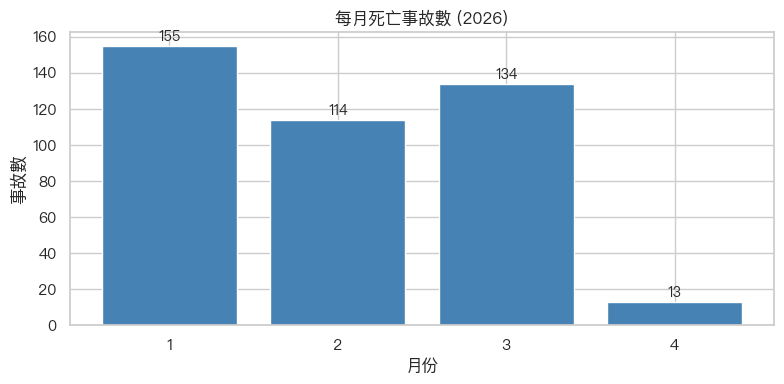

In [26]:
# 每月事故數
monthly = acc.groupby('accident_month')['death_count'].agg(['count', 'sum']).reset_index()
monthly.columns = ['month', 'accident_count', 'total_deaths']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(monthly['month'], monthly['accident_count'], color='steelblue')
ax.set_xlabel('月份')
ax.set_ylabel('事故數')
ax.set_title('每月死亡事故數 (2026)')
ax.set_xticks(monthly['month'])
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('../Images/monthly_accident_count.png', dpi=150)
plt.show()

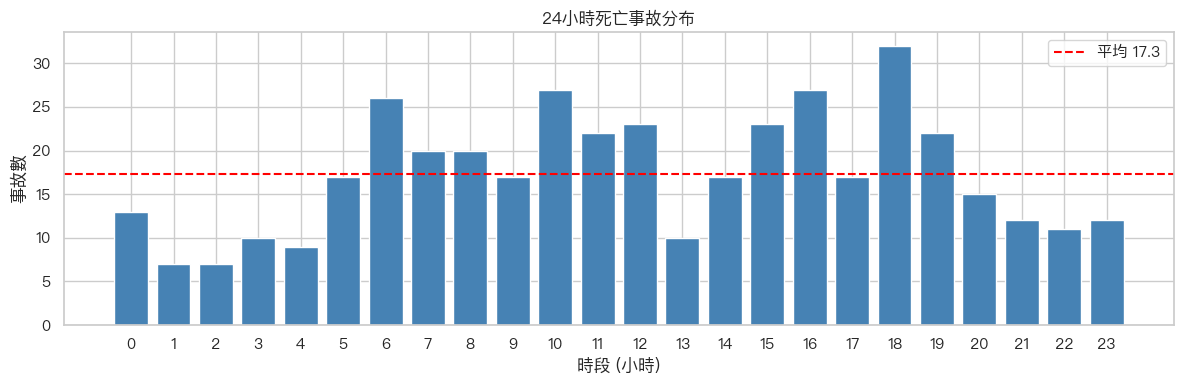

In [27]:
# 24小時事故分布
hourly = acc.groupby('accident_hour').size().reset_index(name='accident_count')

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(hourly['accident_hour'], hourly['accident_count'], color='steelblue')
ax.axhline(hourly['accident_count'].mean(), color='red', linestyle='--', label=f'平均 {hourly["accident_count"].mean():.1f}')
ax.set_xlabel('時段 (小時)')
ax.set_ylabel('事故數')
ax.set_title('24小時死亡事故分布')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.savefig('../Images/hourly_accident_count.png', dpi=150)
plt.show()

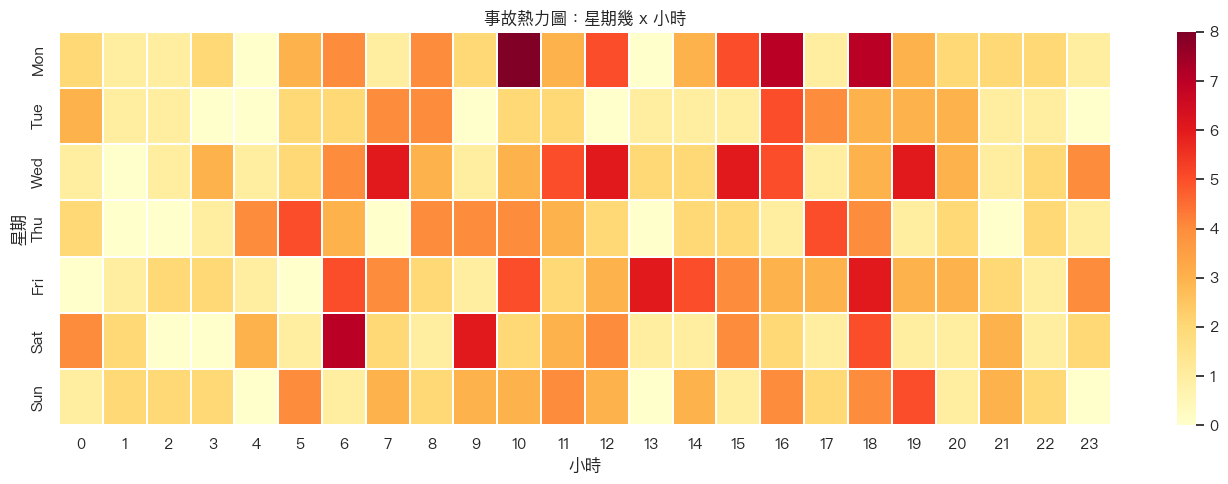

In [28]:
# 熱力圖：小時 x 星期幾
acc['dow'] = pd.to_datetime(acc['accident_date']).dt.dayofweek
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

heatmap_data = acc.groupby(['dow', 'accident_hour']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.3,
            yticklabels=dow_labels, ax=ax)
ax.set_title('事故熱力圖：星期幾 x 小時')
ax.set_xlabel('小時')
ax.set_ylabel('星期')
plt.tight_layout()
plt.savefig('../Images/heatmap_dow_hour.png', dpi=150)
plt.show()

## 4. 肇因分析

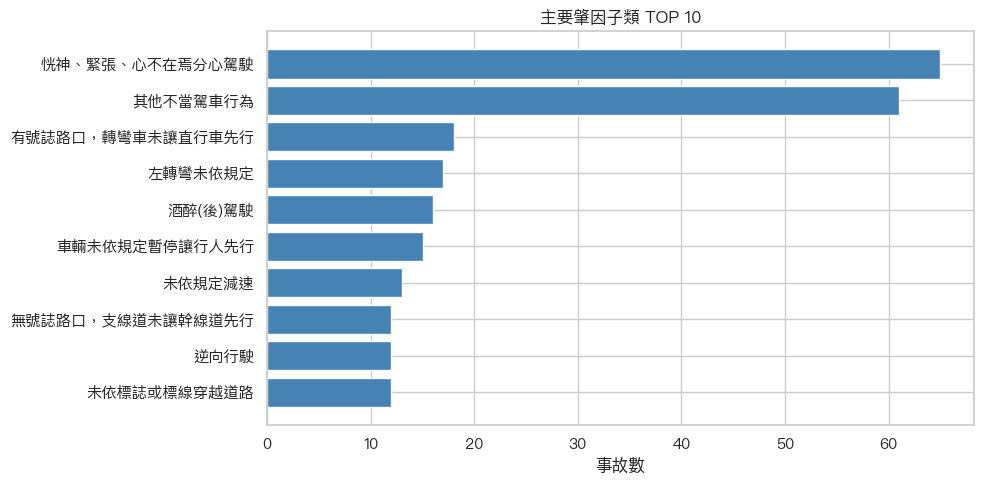

In [29]:
# 主要肇因子類 TOP 10
cause = acc.groupby('cause_minor').size().reset_index(name='count')
cause = cause.dropna(subset=['cause_minor']).sort_values('count', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(cause['cause_minor'][::-1], cause['count'][::-1], color='steelblue')
ax.set_xlabel('事故數')
ax.set_title('主要肇因子類 TOP 10')
plt.tight_layout()
plt.savefig('../Images/top10_cause.png', dpi=150)
plt.show()

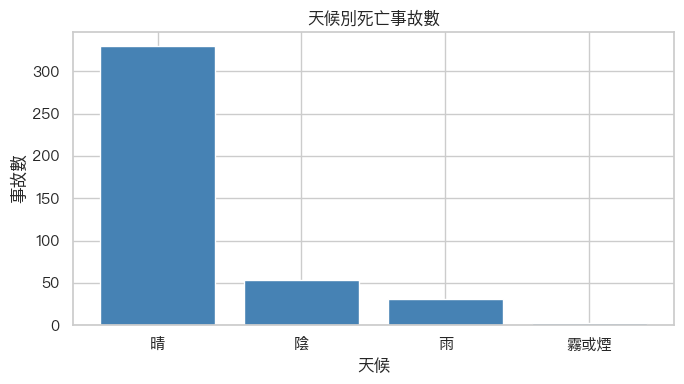

In [30]:
# 天候分布
weather = acc.groupby('weather').size().reset_index(name='count').sort_values('count', ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(weather['weather'], weather['count'], color='steelblue')
ax.set_xlabel('天候')
ax.set_ylabel('事故數')
ax.set_title('天候別死亡事故數')
plt.tight_layout()
plt.savefig('../Images/weather_distribution.png', dpi=150)
plt.show()

## 5. 當事者輪廓

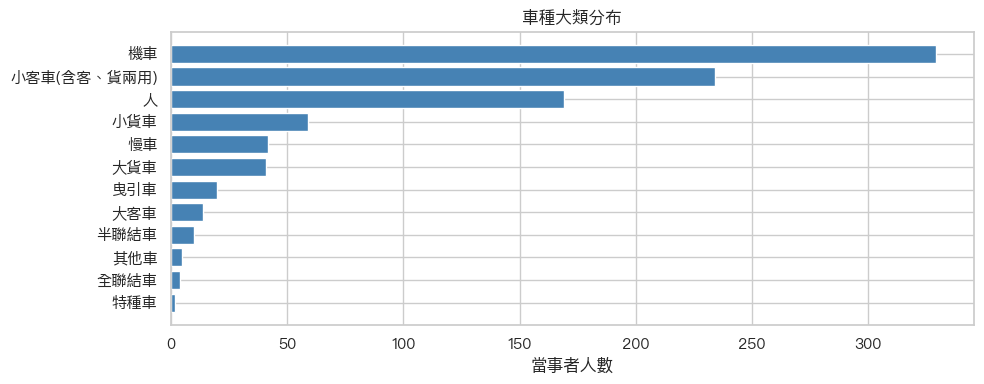

In [31]:
# 車種分布
vehicle = df.groupby('party_type_major').size().reset_index(name='count')
vehicle = vehicle.dropna(subset=['party_type_major']).sort_values('count', ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(vehicle['party_type_major'][::-1], vehicle['count'][::-1], color='steelblue')
ax.set_xlabel('當事者人數')
ax.set_title('車種大類分布')
plt.tight_layout()
plt.savefig('../Images/vehicle_type_distribution.png', dpi=150)
plt.show()

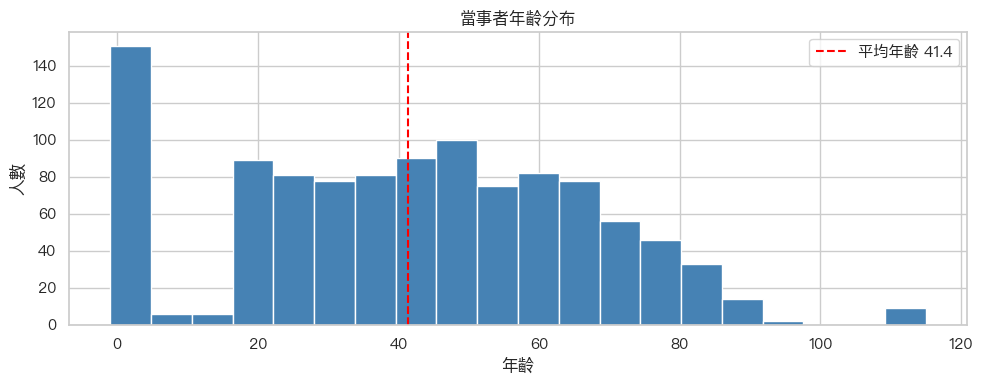

In [32]:
# 年齡分布 (histogram)
age_data = df['age'].dropna()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(age_data, bins=20, color='steelblue', edgecolor='white')
ax.axvline(age_data.mean(), color='red', linestyle='--', label=f'平均年齡 {age_data.mean():.1f}')
ax.set_xlabel('年齡')
ax.set_ylabel('人數')
ax.set_title('當事者年齡分布')
ax.legend()
plt.tight_layout()
plt.savefig('../Images/age_distribution.png', dpi=150)
plt.show()

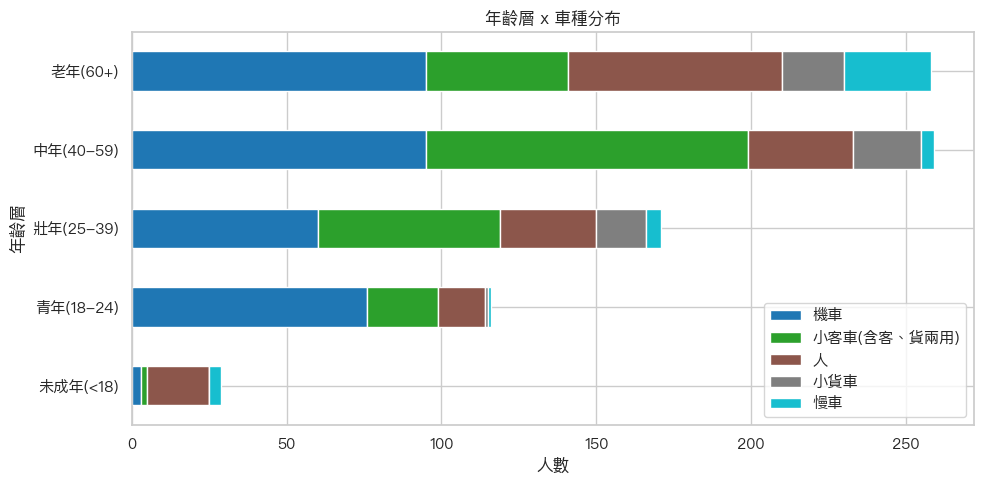

In [33]:
# 年齡層 x 車種 堆疊橫條圖
age_vehicle = df.groupby(['age_group', 'party_type_major']).size().unstack(fill_value=0)
age_order = ['未成年(<18)', '青年(18-24)', '壯年(25-39)', '中年(40-59)', '老年(60+)']
top_vehicles = ['機車', '小客車(含客、貨兩用)', '人', '小貨車', '慢車']

age_vehicle = age_vehicle.reindex(age_order).fillna(0)
cols = [c for c in top_vehicles if c in age_vehicle.columns]

age_vehicle[cols].plot(kind='barh', stacked=True, figsize=(10, 5), colormap='tab10')
plt.title('年齡層 x 車種分布')
plt.xlabel('人數')
plt.ylabel('年齡層')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../Images/age_vehicle_stacked.png', dpi=150)
plt.show()

## 6. 致死率分析 (deaths / accidents)

In [34]:
# 各天候的致死率
lethality = acc.groupby('weather').agg(
    accident_count=('death_count', 'count'),
    total_deaths=('death_count', 'sum')
).reset_index()
lethality['lethality_rate'] = (lethality['total_deaths'] / lethality['accident_count']).round(3)
lethality = lethality.sort_values('lethality_rate', ascending=False)

print(lethality.to_string(index=False))

weather  accident_count  total_deaths  lethality_rate
      雨              31            33           1.065
      陰              53            56           1.057
      晴             330           335           1.015
    霧或煙               2             2           1.000


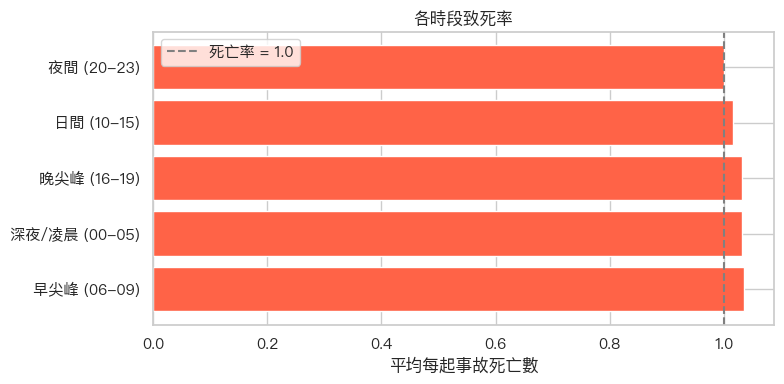

In [35]:
# 各時段的致死率
def time_period(h):
    if 6 <= h <= 9:   return '早尖峰 (06-09)'
    elif 10 <= h <= 15: return '日間 (10-15)'
    elif 16 <= h <= 19: return '晚尖峰 (16-19)'
    elif 20 <= h <= 23: return '夜間 (20-23)'
    else: return '深夜/凌晨 (00-05)'

acc['time_period'] = acc['accident_hour'].apply(time_period)

period_lethality = acc.groupby('time_period').agg(
    accident_count=('death_count', 'count'),
    total_deaths=('death_count', 'sum')
).reset_index()
period_lethality['lethality_rate'] = (period_lethality['total_deaths'] / period_lethality['accident_count']).round(3)
period_lethality = period_lethality.sort_values('lethality_rate', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(period_lethality['time_period'], period_lethality['lethality_rate'], color='tomato')
ax.axvline(1.0, color='gray', linestyle='--', label='死亡率 = 1.0')
ax.set_xlabel('平均每起事故死亡數')
ax.set_title('各時段致死率')
ax.legend()
plt.tight_layout()
plt.savefig('../Images/lethality_by_period.png', dpi=150)
plt.show()